# World Cup 2026 Simulator — Maher Attack/Defense Model

This version replaces the single-ELO scoring model with a **Maher (1982) attack/defense model** fit by maximum likelihood from 8 years of international match results.

**What changes vs the ELO-only version**:
- Each team now has two latent parameters: `attack` (α) and `defense` (β)
- Match goals are Poisson with `λ = α_attacker × β_defender × home_advantage`
- Defensive teams produce lower-scoring matches; offensive teams produce higher-scoring ones, even at equal "overall strength"
- Italy-style "score little, concede little" teams emerge naturally from the fit

**Data**:
- Source: International match results (results_clean.csv, 49,287 matches since 1872)
- Fit window: matches from June 2018 onward (~7,800 matches)
- Match weighting: exponential time decay (half-life 2 years) × importance weight (WC = 1.0, friendlies = 0.5)

**Falls back to ELO-derived priors** for teams with insufficient match history (none in this tournament — all 48 teams have 50+ matches in the window — but the code supports it).

In [95]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Optional
from collections import defaultdict
from scipy.optimize import minimize
import itertools
from collections import defaultdict

rng = np.random.default_rng(seed=42)

# Tournament uses some name variants vs the results dataset
# Map tournament names → results.csv names
TOURNAMENT_TO_DATASET = {
    'Korea Republic': 'South Korea',
    'Czechia': 'Czech Republic',
    "Côte d'Ivoire": 'Ivory Coast',
    'USA': 'United States',
    'Türkiye': 'Turkey',
}
# Reverse map for displaying back
DATASET_TO_TOURNAMENT = {v: k for k, v in TOURNAMENT_TO_DATASET.items()}

def toDatasetName(name: str) -> str:
    return TOURNAMENT_TO_DATASET.get(name, name)

def toTournamentName(name: str) -> str:
    return DATASET_TO_TOURNAMENT.get(name, name)

GROUP_STAGE_MATCHES = [
    # June 11, 2026
    ("Mexico", "South Africa"),
    ("South Korea", "Czech Republic"),

    # June 12, 2026
    ("Canada", "Bosnia and Herzegovina"),
    ("United States", "Paraguay"),

    # June 13, 2026
    ("Haiti", "Scotland"),
    ("Australia", "Turkey"),
    ("Brazil", "Morocco"),
    ("Qatar", "Switzerland"),

    # June 14, 2026
    ("Ivory Coast", "Ecuador"),
    ("Germany", "Curaçao"),
    ("Netherlands", "Japan"),
    ("Sweden", "Tunisia"),

    # June 15, 2026
    ("Saudi Arabia", "Uruguay"),
    ("Spain", "Cape Verde"),
    ("Iran", "New Zealand"),
    ("Belgium", "Egypt"),
    

    # June 16, 2026
    ("France", "Senegal"),
    ("Iraq", "Norway"),
    ("Argentina", "Algeria"),
    ("Austria", "Jordan"),

    # June 17, 2026
    ("Ghana", "Panama"),
    ("England", "Croatia"),
    ("Portugal", "DR Congo"),
    ("Uzbekistan", "Colombia"),
    

    # Matchday 2
    ("Czech Republic", "South Africa"),
    ("Switzerland", "Bosnia and Herzegovina"),

    ("Canada", "Qatar"),
    ("Mexico", "South Korea"),
    
    ("Brazil", "Haiti"),
    ("Scotland", "Morocco"),
    
    ("United States", "Australia"),
    ("Turkey", "Paraguay"),

    ("Germany", "Ivory Coast"),
    ("Ecuador", "Curaçao"),

    ("Netherlands", "Sweden"),
    ("Tunisia", "Japan"),

    ("Uruguay", "Cape Verde"),
    ("Spain", "Saudi Arabia"),

    ("Belgium", "Iran"),
    ("New Zealand", "Egypt"),
    
    ("Norway", "Senegal"),
    ("France", "Iraq"),
    
    ("Argentina", "Austria"),
    ("Jordan", "Algeria"),

    ("England", "Ghana"),
    ("Panama", "Croatia"),

    ("Portugal", "Uzbekistan"),
    ("Colombia", "DR Congo"),


    # Matchday 3
    ("Scotland", "Brazil"),
    ("Morocco", "Haiti"),

    ("Switzerland", "Canada"),
    ("Bosnia and Herzegovina", "Qatar"),

    ("Czech Republic", "Mexico"),
    ("South Africa", "South Korea"),

    ("Curaçao", "Ivory Coast"),
    ("Ecuador", "Germany"),

    ("Japan", "Sweden"),
    ("Tunisia", "Netherlands"),

    ("Turkey", "United States"),
    ("Paraguay", "Australia"),

    ("Norway", "France"),
    ("Senegal", "Iraq"),

    ("Egypt", "Iran"),
    ("New Zealand", "Belgium"),

    ("Cape Verde", "Saudi Arabia"),
    ("Uruguay", "Spain"),

    ("Panama", "England"),
    ("Croatia", "Ghana"),

    ("Algeria", "Austria"),
    ("Jordan", "Argentina"),

    ("Colombia", "Portugal"),
    ("DR Congo", "Uzbekistan"),

]

## 1. Load match results and apply filters

We use the 8-year window (June 2018 → present) with the data Tyler has already cleaned and normalized.

In [96]:
def loadMatchData(
    path: str = '../data/processed/results_clean.csv',
    startDate: str = '2018-06-01',
) -> pd.DataFrame:
    """Load and filter international match results.
    
    Returns a DataFrame of completed matches with columns:
        date, home_team, away_team, home_score, away_score, tournament, neutral
    Future fixtures (NaN scores) are dropped.
    """
    df = pd.read_csv(path, parse_dates=['date'])
    df = df[df['date'] >= pd.Timestamp(startDate)].copy()
    df = df[df['home_score'].notna() & df['away_score'].notna()].copy()
    df['home_score'] = df['home_score'].astype(int)
    df['away_score'] = df['away_score'].astype(int)
    return df.reset_index(drop=True)


matches = loadMatchData()
print(f"Loaded {len(matches):,} completed matches since 2018-06-01")
print(f"Date range: {matches['date'].min().date()} → {matches['date'].max().date()}")
print(f"Unique teams: {len(set(matches['home_team']) | set(matches['away_team']))}")

Loaded 7,732 completed matches since 2018-06-01
Date range: 2018-06-01 → 2026-03-31
Unique teams: 281


## 2. Match weighting

Two factors multiplied together:

**Importance weight** (based on tournament type):
- Major tournaments (WC, Euros, Copa, AFCON, Asian Cup): 1.0
- Qualifiers: 0.85
- Nations Leagues: 0.75
- Friendlies and other: 0.5

**Time decay**: exponential with 2-year half-life. A match from 2 years ago counts half as much; 4 years ago, a quarter.

In [97]:
# Tournament importance weights
IMPORTANCE_WEIGHTS = {
    'FIFA World Cup': 1.0,
    'UEFA Euro': 1.0,
    'Copa América': 1.0,
    'African Cup of Nations': 1.0,
    'AFC Asian Cup': 1.0,
    'Gold Cup': 0.9,
    'Confederations Cup': 0.9,
    'FIFA World Cup qualification': 0.85,
    'UEFA Euro qualification': 0.85,
    'Copa América qualification': 0.85,
    'African Cup of Nations qualification': 0.85,
    'AFC Asian Cup qualification': 0.85,
    'Gold Cup qualification': 0.85,
    'UEFA Nations League': 0.75,
    'CONCACAF Nations League': 0.75,
    'Friendly': 0.5,
}

def importanceWeight(tournament: str) -> float:
    """Return weight for a tournament; defaults to 0.5 for unknowns (mostly friendlies/minor)."""
    if tournament in IMPORTANCE_WEIGHTS:
        return IMPORTANCE_WEIGHTS[tournament]
    tLower = tournament.lower()
    if 'qualification' in tLower or 'qualifier' in tLower:
        return 0.85
    return 0.5  # default: treat unknowns as friendly-ish


def timeDecayWeight(
    matchDate: pd.Timestamp,
    referenceDate: pd.Timestamp,
    halfLifeDays: float = 730,  # ~2 years
) -> float:
    """Exponential decay weight: weight = 0.5 ** (age_days / half_life_days)."""
    ageDays = (referenceDate - matchDate).days
    return 0.5 ** (ageDays / halfLifeDays)


def computeMatchWeights(
    matches: pd.DataFrame,
    referenceDate: Optional[pd.Timestamp] = None,
    halfLifeDays: float = 730,
) -> np.ndarray:
    """Compute (n_matches,) weight array combining importance and time decay."""
    if referenceDate is None:
        referenceDate = matches['date'].max()
    importance = matches['tournament'].map(importanceWeight).values
    decay = np.array([
        timeDecayWeight(d, referenceDate, halfLifeDays) for d in matches['date']
    ])
    return importance * decay


# Compute weights
weights = computeMatchWeights(matches)
print(f"Weight stats: min={weights.min():.4f}, mean={weights.mean():.4f}, max={weights.max():.4f}")
print(f"Effective sample size: {weights.sum():.0f} (vs {len(matches):,} raw matches)")

Weight stats: min=0.0331, mean=0.2590, max=0.9339
Effective sample size: 2003 (vs 7,732 raw matches)


## 3. Fit the Maher model

**Model**: For a match between home team H and away team A,

$$\lambda_H = \alpha_H \cdot \beta_A \cdot \gamma \quad\text{(home team's expected goals)}$$
$$\lambda_A = \alpha_A \cdot \beta_H \quad\text{(away team's expected goals)}$$

Where:
- $\alpha_i$ = team $i$'s attack strength (higher = scores more)
- $\beta_i$ = team $i$'s defense weakness (higher = concedes more — so good defenses have LOW β)
- $\gamma$ = home advantage multiplier
- Neutral venue matches drop the $\gamma$ term

Goals are Poisson:
$$P(H_{goals}=h, A_{goals}=a) = \frac{e^{-\lambda_H}\lambda_H^h}{h!} \cdot \frac{e^{-\lambda_A}\lambda_A^a}{a!}$$

We fit by **weighted maximum likelihood**:
$$\mathcal{L} = \sum_{\text{matches}} w_m \left[ \log P(h_m | \lambda_H) + \log P(a_m | \lambda_A) \right]$$

**Identifiability**: The model has redundancy (you can scale all $\alpha$ up and all $\beta$ down proportionally without changing $\lambda$). We fix this by constraining $\prod \alpha_i = 1$ (geometric mean = 1), which is the standard approach.

In [98]:
def fitMaherModel(
    matches: pd.DataFrame,
    weights: np.ndarray,
    minMatches: int = 10,
    verbose: bool = True,
) -> dict:
    """Fit Maher attack/defense parameters by weighted MLE with analytical gradient.
    
    The analytical gradient is critical: with ~450 parameters, numerical gradients
    burn through function evaluations and L-BFGS-B fails to converge in the default budget.
    With the analytical gradient, convergence happens in ~300 iterations.
    
    Returns dict with: attack, defense, homeAdv, teams, logLik, converged
    """
    homeCounts = matches['home_team'].value_counts()
    awayCounts = matches['away_team'].value_counts()
    totalCounts = homeCounts.add(awayCounts, fill_value=0).astype(int)
    eligible = sorted(totalCounts[totalCounts >= minMatches].index.tolist())
    teamToIdx = {t: i for i, t in enumerate(eligible)}
    nTeams = len(eligible)
    
    if verbose:
        print(f"Fitting Maher model on {nTeams} teams ({minMatches}+ matches)")
    
    mask = matches['home_team'].isin(teamToIdx) & matches['away_team'].isin(teamToIdx)
    fitMatches = matches[mask].copy().reset_index(drop=True)
    fitWeights = weights[mask.values]
    if verbose:
        print(f"  Matches used: {len(fitMatches):,} ({mask.sum()/len(matches)*100:.1f}% of total)")
    
    homeIdx = fitMatches['home_team'].map(teamToIdx).values
    awayIdx = fitMatches['away_team'].map(teamToIdx).values
    homeGoals = fitMatches['home_score'].values.astype(float)
    awayGoals = fitMatches['away_score'].values.astype(float)
    neutral = fitMatches['neutral'].values.astype(bool)
    nonNeutral = ~neutral
    
    # Parameter layout: [logAlpha_free (n-1), logBeta (n), logGamma (1)]
    # Constraint: sum(logAlpha) = 0 → logAlpha[0] = -sum(logAlpha_free)
    
    def negLogLikAndGrad(params):
        logAlphaFree = params[:nTeams-1]
        logAlpha0 = -logAlphaFree.sum()
        logAlpha = np.concatenate([[logAlpha0], logAlphaFree])
        logBeta = params[nTeams-1:2*nTeams-1]
        logGamma = params[2*nTeams-1]
        
        alpha = np.exp(logAlpha)
        beta = np.exp(logBeta)
        gamma = np.exp(logGamma)
        
        homeAdvFactor = np.where(neutral, 1.0, gamma)
        lambdaH = np.clip(alpha[homeIdx] * beta[awayIdx] * homeAdvFactor, 1e-6, 20)
        lambdaA = np.clip(alpha[awayIdx] * beta[homeIdx], 1e-6, 20)
        
        ll = homeGoals * np.log(lambdaH) - lambdaH + awayGoals * np.log(lambdaA) - lambdaA
        negLL = -(fitWeights * ll).sum()
        
        # Gradient (in log-parameter space):
        # d(log P)/d(logAlpha_k) = sum over matches involving k: (observed - expected)
        resH = fitWeights * (homeGoals - lambdaH)
        resA = fitWeights * (awayGoals - lambdaA)
        
        gradLogAlpha = np.zeros(nTeams)
        np.add.at(gradLogAlpha, homeIdx, resH)
        np.add.at(gradLogAlpha, awayIdx, resA)
        
        gradLogBeta = np.zeros(nTeams)
        np.add.at(gradLogBeta, awayIdx, resH)
        np.add.at(gradLogBeta, homeIdx, resA)
        
        gradLogGamma = resH[nonNeutral].sum()
        
        # Negate for minimization
        gradLogAlpha = -gradLogAlpha
        gradLogBeta = -gradLogBeta
        gradLogGamma = -gradLogGamma
        
        # Chain rule for constraint: gradient w.r.t. each free logAlpha
        # ∂L/∂(logAlpha_free[k]) = ∂L/∂(logAlpha[k+1]) - ∂L/∂(logAlpha[0])
        gradLogAlphaFree = gradLogAlpha[1:] - gradLogAlpha[0]
        
        grad = np.concatenate([gradLogAlphaFree, gradLogBeta, [gradLogGamma]])
        return negLL, grad
    
    x0 = np.zeros(2 * nTeams)
    x0[2*nTeams - 1] = np.log(1.3)
    
    if verbose:
        print(f"  Optimizing {len(x0)} parameters with analytical gradient...")
    result = minimize(negLogLikAndGrad, x0, jac=True, method='L-BFGS-B',
                      options={'maxiter': 5000, 'maxfun': 100000,
                               'gtol': 1e-6, 'ftol': 1e-10})
    
    logAlphaFree = result.x[:nTeams-1]
    logAlpha0 = -logAlphaFree.sum()
    logAlpha = np.concatenate([[logAlpha0], logAlphaFree])
    logBeta = result.x[nTeams-1:2*nTeams-1]
    logGamma = result.x[2*nTeams-1]
    alpha, beta, gamma = np.exp(logAlpha), np.exp(logBeta), np.exp(logGamma)
    
    if verbose:
        print(f"  Converged: {result.success}, iterations: {result.nit}")
        print(f"  Final negLogLik: {result.fun:,.1f}")
        print(f"  Max gradient component: {abs(result.jac).max():.6f}")
        print(f"  Home advantage (gamma): {gamma:.3f}")
    
    return {
        'attack': {t: alpha[i] for i, t in enumerate(eligible)},
        'defense': {t: beta[i] for i, t in enumerate(eligible)},
        'homeAdv': gamma,
        'teams': eligible,
        'logLik': -result.fun,
        'converged': result.success,
    }

def filterMatchesForFit(matches, maxGoalDiff=4):
    """Drop matches with goal differential >= maxGoalDiff from the fit data.
    These are usually qualifier mismatches that inflate strong teams' attack
    and weak teams' defense parameters, leading to over-prediction of blowouts."""
    diff = (matches['home_score'] - matches['away_score']).abs()
    keep = diff < maxGoalDiff
    print(f"Filter: dropping {(~keep).sum():,} matches with {maxGoalDiff}+ goal differential")
    print(f"  Remaining: {keep.sum():,} matches ({keep.mean()*100:.1f}% of original)")
    return matches[keep].reset_index(drop=True)


# Re-fit with filtered data
matchesFiltered = filterMatchesForFit(matches, maxGoalDiff=4)
weightsFiltered = computeMatchWeights(matchesFiltered)

print("\nRe-fitting Maher model on filtered data...")
maherFit = fitMaherModel(matchesFiltered, weightsFiltered)


# Re-run the validation to see the new deltas
sampleRng = np.random.default_rng(42)
nSamples = 10000
fitTeams = list(maherFit['attack'].keys())

modelScorelines = Counter()
for _ in range(nSamples):
    a, b = sampleRng.choice(fitTeams, 2, replace=False)
    lA = maherFit['attack'][a] * maherFit['defense'][b]
    lB = maherFit['attack'][b] * maherFit['defense'][a]
    gA = int(sampleRng.poisson(lA))
    gB = int(sampleRng.poisson(lB))
    high, low = max(gA, gB), min(gA, gB)
    modelScorelines[(high, low)] += 1

# Real distribution comes from UNFILTERED data — we want the model to match reality, not the filtered subset
realScorelines = Counter()
for _, r in matches.iterrows():
    h, l = max(r['home_score'], r['away_score']), min(r['home_score'], r['away_score'])
    realScorelines[(h, l)] += 1

print(f"\n{'Scoreline':<12} {'Real %':<10} {'Model %':<10} {'Diff':<10}")
print("-" * 42)
allScores = sorted(set(realScorelines) | set(modelScorelines),
                   key=lambda x: -(realScorelines.get(x, 0)))
for score in allScores[:15]:
    realPct = realScorelines.get(score, 0) / len(matches) * 100
    modelPct = modelScorelines.get(score, 0) / nSamples * 100
    diff = modelPct - realPct
    print(f"{score[0]}-{score[1]:<10} {realPct:>6.1f}    {modelPct:>6.1f}    {diff:+6.1f}")

# Fit it
print("=" * 60)
maherFit = fitMaherModel(matches, weights, minMatches=10)
print("=" * 60)

Filter: dropping 913 matches with 4+ goal differential
  Remaining: 6,819 matches (88.2% of original)

Re-fitting Maher model on filtered data...
Fitting Maher model on 217 teams (10+ matches)
  Matches used: 6,662 (97.7% of total)
  Optimizing 434 parameters with analytical gradient...
  Converged: True, iterations: 269
  Final negLogLik: 3,011.9
  Max gradient component: 0.005556
  Home advantage (gamma): 1.179

Scoreline    Real %     Model %    Diff      
------------------------------------------
1-0            19.2      20.1      +0.9
2-0            12.8      13.9      +1.1
2-1            12.5      10.3      -2.3
1-1            10.3       8.6      -1.7
0-0             8.5       9.0      +0.5
3-0             7.5       8.7      +1.2
3-1             5.3       4.8      -0.5
4-0             4.4       5.2      +0.8
2-2             3.6       2.4      -1.1
3-2             3.3       2.1      -1.2
4-1             2.6       2.3      -0.3
5-0             2.3       2.9      +0.6
6-0          

## 4. Inspect the fit

Let's verify the parameters look sensible. Top attacking teams should be Spain, Germany, England etc. Best defenses should be teams like Morocco, Italy, Argentina.

In [99]:
# Build summary DataFrame
summary = pd.DataFrame([
    {'team': t,
     'attack': maherFit['attack'][t],
     'defense': maherFit['defense'][t],
     'attackMinusDefense': maherFit['attack'][t] - maherFit['defense'][t]}
    for t in maherFit['teams']
])

print("Top 15 ATTACK strength (scores most vs avg defense):")
print(summary.nlargest(15, 'attack')[['team', 'attack', 'defense']].to_string(index=False))

print("\nTop 15 DEFENSE (lowest beta = concedes least):")
print(summary.nsmallest(15, 'defense')[['team', 'attack', 'defense']].to_string(index=False))

print("\nTop 15 OVERALL (attack - defense, our proxy for total strength):")
print(summary.nlargest(15, 'attackMinusDefense')[['team', 'attack', 'defense', 'attackMinusDefense']].to_string(index=False))

Top 15 ATTACK strength (scores most vs avg defense):
       team   attack  defense
      Spain 4.586185 0.275858
    Germany 3.906721 0.415478
   Portugal 3.890535 0.334270
     Brazil 3.786381 0.297843
Netherlands 3.772977 0.382169
  Argentina 3.719333 0.213741
     France 3.696509 0.304831
   Colombia 3.646805 0.347141
    England 3.563768 0.257420
     Norway 3.457694 0.416208
    Belgium 3.285672 0.390158
Switzerland 3.205162 0.409662
    Denmark 3.041372 0.381007
    Croatia 2.988821 0.388617
      Italy 2.947472 0.415688

Top 15 DEFENSE (lowest beta = concedes least):
       team   attack  defense
  Argentina 3.719333 0.213741
    Morocco 2.503808 0.249307
    England 3.563768 0.257420
    Ecuador 2.111388 0.258902
      Spain 4.586185 0.275858
    Uruguay 2.446191 0.289305
     Brazil 3.786381 0.297843
     France 3.696509 0.304831
   Portugal 3.890535 0.334270
   Colombia 3.646805 0.347141
       Mali 1.709211 0.356695
    Senegal 2.586065 0.362047
      Japan 2.919232 0.362244

## 5. New scoring function — Maher-based

Replaces the ELO-based `predictScore`. Same signature so it slots into the existing simulator.

In [100]:
def predictScoreMaher(
    teamA: str,
    teamB: str,
    maherFit: dict,
    rng: np.random.Generator,
    homeTeam: Optional[str] = None,  # if A or B is "home" (non-neutral)
) -> tuple[int, int]:
    """Sample a match score using Maher attack/defense parameters.
    
    Args:
        teamA, teamB: team names (use tournament names; gets mapped to dataset names internally)
        maherFit: result of fitMaherModel
        rng: numpy Generator
        homeTeam: if specified and equal to teamA or teamB, applies home advantage to that team.
                  None means neutral venue (default for World Cup matches).
    
    Returns:
        (goalsA, goalsB) integer tuple
    """
    # Map to dataset names
    aData = toDatasetName(teamA)
    bData = toDatasetName(teamB)
    
    alphaA = maherFit['attack'].get(aData)
    betaA = maherFit['defense'].get(aData)
    alphaB = maherFit['attack'].get(bData)
    betaB = maherFit['defense'].get(bData)
    
    if any(p is None for p in [alphaA, betaA, alphaB, betaB]):
        missing = [t for t, p in zip([teamA, teamB], [alphaA, alphaB]) if p is None]
        raise KeyError(f"Maher parameters not found for: {missing}")
    
    gamma = maherFit['homeAdv']
    
    # Apply home advantage
    homeFactorA = gamma if homeTeam == teamA else 1.0
    homeFactorB = gamma if homeTeam == teamB else 1.0
    
    lambdaA = alphaA * betaB * homeFactorA
    lambdaB = alphaB * betaA * homeFactorB
    
    # Sample
    goalsA = int(rng.poisson(np.clip(lambdaA, 0, 20)))
    goalsB = int(rng.poisson(np.clip(lambdaB, 0, 20)))
    return goalsA, goalsB


# Sanity checks
print("Spain vs Curaçao (neutral):", predictScoreMaher('Spain', 'Curaçao', maherFit, rng))
print("Mexico (home) vs Korea Republic:", predictScoreMaher('Mexico', 'Korea Republic', maherFit, rng, homeTeam='Mexico'))
print("Argentina vs France (neutral):", predictScoreMaher('Argentina', 'France', maherFit, rng))
print("Italy-style test — Morocco (defense) vs Senegal:", predictScoreMaher('Morocco', 'Senegal', maherFit, rng))
print()

# Expected goals comparison
print("Expected goals (deterministic):")
for a, b in [('Spain', 'Curaçao'), ('Argentina', 'France'), ('Brazil', 'Morocco'), ('Germany', 'Belgium')]:
    aD, bD = toDatasetName(a), toDatasetName(b)
    lambdaA = maherFit['attack'][aD] * maherFit['defense'][bD]
    lambdaB = maherFit['attack'][bD] * maherFit['defense'][aD]
    print(f"  {a:<12} {lambdaA:.2f} - {lambdaB:.2f} {b}")

Spain vs Curaçao (neutral): (6, 1)
Mexico (home) vs Korea Republic: (1, 3)
Argentina vs France (neutral): (0, 1)
Italy-style test — Morocco (defense) vs Senegal: (2, 0)

Expected goals (deterministic):
  Spain        4.22 - 0.31 Curaçao
  Argentina    1.13 - 0.79 France
  Brazil       0.94 - 0.75 Morocco
  Germany      1.52 - 1.37 Belgium


In [101]:
for match in GROUP_STAGE_MATCHES:
    try:
        score = predictScoreMaher(match[0], match[1], maherFit, rng)
        print(f"{match[0]:<12} vs {match[1]:<12}:   {score[0]} - {score[1]}")
    except KeyError as e:
        print(f"{match[0]:<12} vs {match[1]:<12} → prediction failed: {e}")

Mexico       vs South Africa:   3 - 0
South Korea  vs Czech Republic:   0 - 0
Canada       vs Bosnia and Herzegovina:   3 - 0
United States vs Paraguay    :   1 - 0
Haiti        vs Scotland    :   0 - 2
Australia    vs Turkey      :   2 - 2
Brazil       vs Morocco     :   0 - 1
Qatar        vs Switzerland :   0 - 0
Ivory Coast  vs Ecuador     :   1 - 2
Germany      vs Curaçao     :   2 - 1
Netherlands  vs Japan       :   3 - 1
Sweden       vs Tunisia     :   0 - 1
Saudi Arabia vs Uruguay     :   0 - 1
Spain        vs Cape Verde  :   1 - 0
Iran         vs New Zealand :   3 - 0
Belgium      vs Egypt       :   1 - 0
France       vs Senegal     :   0 - 1
Iraq         vs Norway      :   0 - 1
Argentina    vs Algeria     :   2 - 0
Austria      vs Jordan      :   2 - 0
Ghana        vs Panama      :   3 - 3
England      vs Croatia     :   1 - 1
Portugal     vs DR Congo    :   1 - 0
Uzbekistan   vs Colombia    :   0 - 4
Czech Republic vs South Africa:   2 - 1
Switzerland  vs Bosnia and Herzegov

## 6. Tournament structure

Same as previous version — official 2026 groups.

In [102]:
HOST_NATIONS = {'USA', 'Canada', 'Mexico'}

GROUPS = {
    'A': ['Mexico', 'South Africa', 'Korea Republic', 'Czechia'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['USA', 'Paraguay', 'Australia', 'Türkiye'],
    'E': ['Germany', 'Curaçao', "Côte d'Ivoire", 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

# Verify all teams have Maher parameters
allGroupTeams = list(itertools.chain.from_iterable(GROUPS.values()))
missing = []
for t in allGroupTeams:
    if toDatasetName(t) not in maherFit['attack']:
        missing.append(t)
if missing:
    print(f"⚠ Missing Maher parameters for: {missing}")
else:
    print(f"✓ All 48 teams have fitted Maher parameters")

✓ All 48 teams have fitted Maher parameters


## 7. Knockout match resolution (Maher version)

In [103]:
def simulatePenalties(
    teamA: str,
    teamB: str,
    maherFit: dict,
    rng: np.random.Generator,
) -> tuple[int, int]:
    """Simulate penalty shootout. Skill edge from Maher overall strength (attack - defense)."""
    aData = toDatasetName(teamA)
    bData = toDatasetName(teamB)
    # Skill proxy: log ratio of (attack / defense) — high alpha + low beta means strong
    strA = np.log(maherFit['attack'][aData] / maherFit['defense'][aData])
    strB = np.log(maherFit['attack'][bData] / maherFit['defense'][bData])
    edge = np.clip((strA - strB) * 0.05, -0.05, 0.05)
    pA = 0.75 + edge
    pB = 0.75 - edge
    
    scoreA, scoreB = 0, 0
    for kick in range(5):
        remainingA = 5 - kick
        remainingB = 5 - kick - 1
        if rng.random() < pA: scoreA += 1
        if scoreB + remainingB < scoreA: return scoreA, scoreB
        if rng.random() < pB: scoreB += 1
        if scoreA + remainingA - 1 < scoreB: return scoreA, scoreB
    
    while scoreA == scoreB:
        if rng.random() < pA: scoreA += 1
        if rng.random() < pB: scoreB += 1
    
    return scoreA, scoreB


def predictKnockoutScoreMaher(
    teamA: str,
    teamB: str,
    maherFit: dict,
    rng: np.random.Generator,
    homeTeam: Optional[str] = None,
    etScale: float = 1/3,
) -> dict:
    """Knockout match: 90' → ET → penalties."""
    aData = toDatasetName(teamA)
    bData = toDatasetName(teamB)
    gamma = maherFit['homeAdv']
    
    homeFactorA = gamma if homeTeam == teamA else 1.0
    homeFactorB = gamma if homeTeam == teamB else 1.0
    
    # 90 minutes
    lambdaA90 = maherFit['attack'][aData] * maherFit['defense'][bData] * homeFactorA
    lambdaB90 = maherFit['attack'][bData] * maherFit['defense'][aData] * homeFactorB
    a90 = int(rng.poisson(lambdaA90))
    b90 = int(rng.poisson(lambdaB90))
    
    if a90 != b90:
        return {'goals90': (a90, b90), 'goalsET': None, 'pens': None,
                'winner': 'A' if a90 > b90 else 'B',
                'decidedIn': '90', 'finalScore': (a90, b90)}
    
    # Extra time
    aET = int(rng.poisson(lambdaA90 * etScale))
    bET = int(rng.poisson(lambdaB90 * etScale))
    aTotal = a90 + aET
    bTotal = b90 + bET
    
    if aTotal != bTotal:
        return {'goals90': (a90, b90), 'goalsET': (aET, bET), 'pens': None,
                'winner': 'A' if aTotal > bTotal else 'B',
                'decidedIn': 'ET', 'finalScore': (aTotal, bTotal)}
    
    # Penalties
    penA, penB = simulatePenalties(teamA, teamB, maherFit, rng)
    return {'goals90': (a90, b90), 'goalsET': (aET, bET), 'pens': (penA, penB),
            'winner': 'A' if penA > penB else 'B',
            'decidedIn': 'PEN', 'finalScore': (aTotal, bTotal)}


# Sanity
print("Knockout sample: Spain vs France")
print(predictKnockoutScoreMaher('Spain', 'France', maherFit, rng))

Knockout sample: Spain vs France
{'goals90': (0, 1), 'goalsET': None, 'pens': None, 'winner': 'B', 'decidedIn': '90', 'finalScore': (0, 1)}


## 8. Group + knockout simulation

In [104]:
@dataclass
class TeamRecord:
    name: str
    played: int = 0
    wins: int = 0
    draws: int = 0
    losses: int = 0
    goalsFor: int = 0
    goalsAgainst: int = 0
    
    @property
    def points(self) -> int:
        return self.wins * 3 + self.draws
    
    @property
    def goalDiff(self) -> int:
        return self.goalsFor - self.goalsAgainst
    
    def applyResult(self, scored, conceded):
        self.played += 1
        self.goalsFor += scored
        self.goalsAgainst += conceded
        if scored > conceded: self.wins += 1
        elif scored == conceded: self.draws += 1
        else: self.losses += 1


# Name mapping: GROUP_STAGE_MATCHES uses dataset names, GROUPS uses tournament names
DATASET_TO_TOURNAMENT = {
    'South Korea': 'Korea Republic', 'Czech Republic': 'Czechia',
    'Ivory Coast': "Côte d'Ivoire", 'United States': 'USA', 'Turkey': 'Türkiye',
}
def toTournament(name): return DATASET_TO_TOURNAMENT.get(name, name)


def simulateGroupStageFromSchedule(matchList, groups, maherFit, hostNations, rng):
    """Simulate group stage using the explicit match schedule.
    Returns (standings_by_group, list_of_match_results in schedule order)."""
    teamToGroup = {t: g for g, teams in groups.items() for t in teams}
    records = {t: TeamRecord(name=t) for teams in groups.values() for t in teams}
    matchResults = []
    
    for a, b in matchList:
        aT, bT = toTournament(a), toTournament(b)
        home = aT if aT in hostNations else (bT if bT in hostNations else None)
        ga, gb = predictScoreMaher(aT, bT, maherFit, rng, homeTeam=home)
        records[aT].applyResult(ga, gb)
        records[bT].applyResult(gb, ga)
        matchResults.append({
            'group': teamToGroup[aT], 'teamA': aT, 'teamB': bT,
            'goalsA': ga, 'goalsB': gb,
        })
    
    standings = {g: rankGroup({t: records[t] for t in teams}) for g, teams in groups.items()}
    return standings, matchResults


def rankGroup(records):
    return sorted(records.values(),
                  key=lambda r: (r.points, r.goalDiff, r.goalsFor),
                  reverse=True)


def selectQualifiers(groupResults):
    winners, runnersUp, allThird, eliminated = {}, {}, [], []
    for gName, ranking in groupResults.items():
        winners[gName] = ranking[0]
        runnersUp[gName] = ranking[1]
        allThird.append((gName, ranking[2]))
        eliminated.append(ranking[3])
    rankedThirds = sorted(allThird,
                          key=lambda x: (x[1].points, x[1].goalDiff, x[1].goalsFor),
                          reverse=True)
    qualifyingThirds = rankedThirds[:8]
    for gName, rec in rankedThirds[8:]:
        eliminated.append(rec)
    return {'winners': winners, 'runnersUp': runnersUp,
            'qualifyingThirds': qualifyingThirds, 'eliminated': eliminated}


def buildRoundOf32(qualifiers):
    winners = sorted(qualifiers['winners'].values(),
                     key=lambda r: (r.points, r.goalDiff, r.goalsFor), reverse=True)
    runnersUp = sorted(qualifiers['runnersUp'].values(),
                       key=lambda r: (r.points, r.goalDiff, r.goalsFor), reverse=True)
    thirds = [rec for _, rec in qualifiers['qualifyingThirds']]
    
    matchups = []
    for w, t in zip(winners[:8], reversed(thirds)):
        matchups.append((w, t))
    for w, r in zip(winners[8:12], runnersUp[:4]):
        matchups.append((w, r))
    remaining = runnersUp[4:]
    for i in range(0, len(remaining), 2):
        matchups.append((remaining[i], remaining[i+1]))
    return matchups


def simulateKnockoutRoundMaher(matchups, maherFit, rng, roundName=''):
    winners, results = [], []
    for tA, tB in matchups:
        outcome = predictKnockoutScoreMaher(tA.name, tB.name, maherFit, rng)
        winner = tA if outcome['winner'] == 'A' else tB
        loser = tB if outcome['winner'] == 'A' else tA
        winners.append(winner)
        results.append({'round': roundName, 'teamA': tA, 'teamB': tB,
                        'score90': outcome['goals90'], 'scoreET': outcome['goalsET'],
                        'pens': outcome['pens'], 'finalScore': outcome['finalScore'],
                        'decidedIn': outcome['decidedIn'],
                        'winner': winner, 'loser': loser})
    return winners, results


def simulateKnockoutBracketMaher(roundOf32, maherFit, rng):
    allResults = []
    r16Teams, r = simulateKnockoutRoundMaher(roundOf32, maherFit, rng, 'R32'); allResults.extend(r)
    r16M = [(r16Teams[i], r16Teams[i+1]) for i in range(0, 16, 2)]
    qfTeams, r = simulateKnockoutRoundMaher(r16M, maherFit, rng, 'R16'); allResults.extend(r)
    qfM = [(qfTeams[i], qfTeams[i+1]) for i in range(0, 8, 2)]
    sfTeams, r = simulateKnockoutRoundMaher(qfM, maherFit, rng, 'QF'); allResults.extend(r)
    sfM = [(sfTeams[i], sfTeams[i+1]) for i in range(0, 4, 2)]
    finalists, r = simulateKnockoutRoundMaher(sfM, maherFit, rng, 'SF'); allResults.extend(r)
    sfLosers = [m['loser'] for m in r]
    third, tpr = simulateKnockoutRoundMaher([(sfLosers[0], sfLosers[1])], maherFit, rng, '3rd Place')
    allResults.extend(tpr)
    champs, fr = simulateKnockoutRoundMaher([(finalists[0], finalists[1])], maherFit, rng, 'FINAL')
    allResults.extend(fr)
    fourth = sfLosers[1] if third[0].name == sfLosers[0].name else sfLosers[0]
    return {'allResults': allResults, 'champion': champs[0],
            'runnerUp': finalists[1] if champs[0].name == finalists[0].name else finalists[0],
            'third': third[0], 'fourth': fourth,
            'semifinalists': [t.name for t in sfTeams],
            'quarterfinalists': [t.name for t in qfTeams]}


def simulateTournamentMaher(groups, matchList, maherFit, hostNations, rng):
    groupResults, groupMatches = simulateGroupStageFromSchedule(
        matchList, groups, maherFit, hostNations, rng)
    qualifiers = selectQualifiers(groupResults)
    r32 = buildRoundOf32(qualifiers)
    ko = simulateKnockoutBracketMaher(r32, maherFit, rng)
    return {'groupResults': groupResults, 'groupMatches': groupMatches,
            'qualifiers': qualifiers, 'knockoutResults': ko['allResults'],
            'champion': ko['champion'].name, 'runnerUp': ko['runnerUp'].name,
            'third': ko['third'].name, 'fourth': ko['fourth'].name,
            'semifinalists': ko['semifinalists'],
            'quarterfinalists': ko['quarterfinalists']}


# Single run
sim = simulateTournamentMaher(GROUPS, GROUP_STAGE_MATCHES, maherFit, HOST_NATIONS,
                              np.random.default_rng(42))
print(f"Champion: {sim['champion']}")
print(f"Runner-up: {sim['runnerUp']}")
print(f"Third: {sim['third']}")
print(f"Semi-finalists: {sim['semifinalists']}")

Champion: Brazil
Runner-up: Spain
Third: Norway
Semi-finalists: ['Spain', 'Switzerland', 'Norway', 'Brazil']


## 9. Monte Carlo

Run 1000 tournaments and aggregate.

In [105]:
from collections import defaultdict


def assignFinishPositions(sim):
    """Assign integer finish position per team for one tournament."""
    positions = {}
    positions[sim['champion']] = 1
    positions[sim['runnerUp']] = 2
    positions[sim['third']] = 3
    positions[sim['fourth']] = 4
    for m in sim['knockoutResults']:
        loserName = m['loser'].name
        if loserName in positions: continue
        if m['round'] == 'QF': positions[loserName] = 6
        elif m['round'] == 'R16': positions[loserName] = 12
        elif m['round'] == 'R32': positions[loserName] = 24
    for ranking in sim['groupResults'].values():
        for rec in ranking:
            if rec.name not in positions:
                positions[rec.name] = 40
    return positions


def runMonteCarloMaher(nSims, groups, matchList, maherFit, hostNations, baseSeed=0):
    """Run nSims tournaments. Returns:
        summaryDf: per-team probabilities and finish stats
        positionsByTeam: {team: [positions across sims]}
        groupMatchSamples: {(teamA, teamB): [(gA, gB), ...]} — schedule-order keyed
    """
    allTeams = list(itertools.chain.from_iterable(groups.values()))
    positionsByTeam = {t: [] for t in allTeams}
    groupMatchSamples = defaultdict(list)
    champions, runnersUp, thirds, fourths, sfs, qfs = [], [], [], [], [], []
    
    for i in range(nSims):
        simRng = np.random.default_rng(baseSeed + i)
        sim = simulateTournamentMaher(groups, matchList, maherFit, hostNations, simRng)
        champions.append(sim['champion'])
        runnersUp.append(sim['runnerUp'])
        thirds.append(sim['third'])
        fourths.append(sim['fourth'])
        sfs.extend(sim['semifinalists'])
        qfs.extend(sim['quarterfinalists'])
        
        positions = assignFinishPositions(sim)
        for t, p in positions.items():
            positionsByTeam[t].append(p)
        
        for m in sim['groupMatches']:
            groupMatchSamples[(m['teamA'], m['teamB'])].append((m['goalsA'], m['goalsB']))
    
    summary = []
    for team in allTeams:
        tData = toDatasetName(team)
        ps = positionsByTeam[team]
        summary.append({
            'team': team,
            'attack': maherFit['attack'].get(tData, np.nan),
            'defense': maherFit['defense'].get(tData, np.nan),
            'titleProb': champions.count(team) / nSims,
            'finalProb': (champions.count(team) + runnersUp.count(team)) / nSims,
            'sfProb': sfs.count(team) / nSims,
            'qfProb': qfs.count(team) / nSims,
            'bestFinish': min(ps),
            'medianFinish': int(np.median(ps)),
            'worstFinish': max(ps),
            'meanFinish': round(np.mean(ps), 1),
        })
    summaryDf = pd.DataFrame(summary).sort_values('titleProb', ascending=False).reset_index(drop=True)
    return summaryDf, positionsByTeam, groupMatchSamples


# === Run the MC ===
print("Running 1000 simulations...")
mcResults, positionsByTeam, groupMatchSamples = runMonteCarloMaher(
    1000, GROUPS, GROUP_STAGE_MATCHES, maherFit, HOST_NATIONS, baseSeed=1000
)


# === Per-team probabilities + finish range ===
print("\nTop 20 by title probability:")
print(mcResults.head(20).to_string(index=False))


# === Group match: distribution + modal "bracket pick" scoreline ===
def matchPickAndDist(samples, topN=5):
    """Return (modal_scoreline, modal_pct, top_N_df, mean_a, mean_b, win_probs)."""
    counts = defaultdict(int)
    for gA, gB in samples:
        counts[(gA, gB)] += 1
    n = len(samples)
    sortedScores = sorted(counts.items(), key=lambda x: -x[1])
    modal = sortedScores[0][0]
    modalPct = sortedScores[0][1] / n * 100
    topDf = pd.DataFrame([
        {'scoreline': f"{s[0]}-{s[1]}", 'count': c, 'pct': round(c/n*100, 1)}
        for s, c in sortedScores[:topN]
    ])
    meanA = np.mean([s[0] for s in samples])
    meanB = np.mean([s[1] for s in samples])
    wA = sum(1 for a, b in samples if a > b) / n
    dr = sum(1 for a, b in samples if a == b) / n
    wB = sum(1 for a, b in samples if a < b) / n
    return modal, modalPct, topDf, meanA, meanB, (wA, dr, wB)


# Walk every match in schedule order
print("\n" + "=" * 78)
print("GROUP STAGE — predicted scorelines (modal of 1000 sims) + top alternatives")
print("=" * 78)

matchdays = [(0, 24, "MATCHDAY 1"), (24, 48, "MATCHDAY 2"), (48, 72, "MATCHDAY 3")]
bracketPicks = {}  # (teamA, teamB) → (gA, gB) for use in deterministic bracket below

for start, end, label in matchdays:
    print(f"\n--- {label} ---")
    for a, b in GROUP_STAGE_MATCHES[start:end]:
        aT, bT = toTournament(a), toTournament(b)
        samples = groupMatchSamples.get((aT, bT))
        if samples is None:
            print(f"  ⚠ No samples for {aT} vs {bT}")
            continue
        modal, modalPct, topDf, meanA, meanB, (wA, dr, wB) = matchPickAndDist(samples)
        bracketPicks[(aT, bT)] = modal
        print(f"\n  {aT} vs {bT}")
        print(f"    PICK: {modal[0]}-{modal[1]} ({modalPct:.1f}% of sims)   "
              f"Expected: {meanA:.2f}-{meanB:.2f}   "
              f"P({aT})={wA:.2f} P(draw)={dr:.2f} P({bT})={wB:.2f}")
        print(f"    Top alternatives: " + ", ".join(
            f"{r['scoreline']} ({r['pct']}%)" for _, r in topDf.iterrows()
        ))


# === Build the deterministic bracket from modal scorelines ===
print("\n" + "=" * 78)
print("DETERMINISTIC BRACKET — using modal scorelines")
print("=" * 78)

def buildStandingsFromPicks(matchList, picks, groups):
    """Apply modal scorelines to build group standings."""
    teamToGroup = {t: g for g, teams in groups.items() for t in teams}
    records = {t: TeamRecord(name=t) for teams in groups.values() for t in teams}
    for a, b in matchList:
        aT, bT = toTournament(a), toTournament(b)
        gA, gB = picks[(aT, bT)]
        records[aT].applyResult(gA, gB)
        records[bT].applyResult(gB, gA)
    return {g: rankGroup({t: records[t] for t in teams}) for g, teams in groups.items()}


detStandings = buildStandingsFromPicks(GROUP_STAGE_MATCHES, bracketPicks, GROUPS)
for g, ranking in detStandings.items():
    print(f"\nGroup {g}:")
    for i, r in enumerate(ranking):
        marker = " ← W" if i == 0 else (" ← R" if i == 1 else (" ← 3rd" if i == 2 else ""))
        print(f"  {r.name:<24} {r.points:>2} pts  GD {r.goalDiff:+3d}  GF {r.goalsFor:>2}{marker}")


# === Knockout phase: run sims on the deterministic bracket only ===
# Since group standings are now fixed, sample knockouts to get most likely matchup outcomes.
print("\n" + "=" * 78)
print("KNOCKOUT BRACKET — based on deterministic group standings")
print("Running 1000 knockout-only sims to determine modal winner of each match...")
print("=" * 78)

detQualifiers = selectQualifiers(detStandings)
detR32 = buildRoundOf32(detQualifiers)

def simulateBracketManyTimes(roundOf32, maherFit, nSims=1000, baseSeed=5000):
    """Run knockout bracket nSims times from fixed R32, return per-match modal scoreline + winner."""
    # Track each match position in the bracket (R32 has 16 matches, R16 has 8, etc.)
    # Position index is stable across sims because R32 input is fixed.
    matchAccumulator = defaultdict(lambda: {'scorelines': defaultdict(int), 'winners': defaultdict(int)})
    
    for i in range(nSims):
        rng = np.random.default_rng(baseSeed + i)
        allResults = []
        r16Teams, r = simulateKnockoutRoundMaher(roundOf32, maherFit, rng, 'R32'); allResults.extend(r)
        r16M = [(r16Teams[j], r16Teams[j+1]) for j in range(0, 16, 2)]
        qfTeams, r = simulateKnockoutRoundMaher(r16M, maherFit, rng, 'R16'); allResults.extend(r)
        qfM = [(qfTeams[j], qfTeams[j+1]) for j in range(0, 8, 2)]
        sfTeams, r = simulateKnockoutRoundMaher(qfM, maherFit, rng, 'QF'); allResults.extend(r)
        sfM = [(sfTeams[j], sfTeams[j+1]) for j in range(0, 4, 2)]
        finalists, r = simulateKnockoutRoundMaher(sfM, maherFit, rng, 'SF'); allResults.extend(r)
        sfLosers = [m['loser'] for m in r]
        third, tpr = simulateKnockoutRoundMaher([(sfLosers[0], sfLosers[1])], maherFit, rng, '3rd Place')
        allResults.extend(tpr)
        _, fr = simulateKnockoutRoundMaher([(finalists[0], finalists[1])], maherFit, rng, 'FINAL')
        allResults.extend(fr)
        
        # Aggregate by position in the bracket
        for idx, m in enumerate(allResults):
            key = (m['round'], idx, m['teamA'].name, m['teamB'].name)
            matchAccumulator[key]['scorelines'][m['finalScore']] += 1
            matchAccumulator[key]['winners'][m['winner'].name] += 1
    
    return matchAccumulator


knockoutMatchSims = simulateBracketManyTimes(detR32, maherFit, nSims=1000)

# Display modal pick per match
roundOrder = ['R32', 'R16', 'QF', 'SF', '3rd Place', 'FINAL']
print()
for round_name in roundOrder:
    round_matches = [(k, v) for k, v in knockoutMatchSims.items() if k[0] == round_name]
    round_matches.sort(key=lambda x: x[0][1])  # by position
    print(f"\n--- {round_name} ---")
    for (rnd, idx, tA, tB), data in round_matches:
        topScore, topCount = max(data['scorelines'].items(), key=lambda x: x[1])
        topWinner, winCount = max(data['winners'].items(), key=lambda x: x[1])
        print(f"  {tA:<22} {topScore[0]}-{topScore[1]:<2} {tB:<22}  "
              f"→ {topWinner} ({winCount/1000*100:.0f}% of sims)")

Running 1000 simulations...

Top 20 by title probability:
       team   attack  defense  titleProb  finalProb  sfProb  qfProb  bestFinish  medianFinish  worstFinish  meanFinish
  Argentina 3.719333 0.213741      0.190      0.277   0.403   0.593           1             6           40         9.5
      Spain 4.586185 0.275858      0.179      0.280   0.415   0.591           1             6           40         9.2
    England 3.563768 0.257420      0.096      0.179   0.302   0.491           1            12           40        11.1
     Brazil 3.786381 0.297843      0.083      0.165   0.286   0.445           1            12           40        11.8
     France 3.696509 0.304831      0.078      0.137   0.242   0.400           1            12           40        13.6
   Portugal 3.890535 0.334270      0.057      0.129   0.229   0.406           1            12           40        14.3
    Morocco 2.503808 0.249307      0.040      0.087   0.189   0.334           1            12           40   

In [111]:
def simulateMatchup(teamA, teamB, maherFit, nSims=1000, homeTeam=None,
                    knockout=False, baseSeed=None, topN=10):
    """Simulate a head-to-head matchup nSims times and return the scoreline distribution.
    
    Args:
        teamA, teamB: team names (tournament names, e.g. 'Spain', 'Korea Republic')
        maherFit: fitted Maher model dict
        nSims: number of simulations (default 1000)
        homeTeam: if specified, applies home advantage to that team. None = neutral.
        knockout: if True, uses predictKnockoutScoreMaher (resolves draws via ET/pens)
        baseSeed: int seed for reproducibility; None = random
        topN: number of top scorelines to display
    
    Returns:
        dict with: meanA, meanB, modal, modalPct, distDf, winProbs, etRate, penRate
    """
    rng = np.random.default_rng(baseSeed)
    scorelines = defaultdict(int)
    goalsA_list, goalsB_list = [], []
    etCount, penCount = 0, 0
    wA, dr, wB = 0, 0, 0
    
    for _ in range(nSims):
        if knockout:
            outcome = predictKnockoutScoreMaher(teamA, teamB, maherFit, rng, homeTeam=homeTeam)
            gA, gB = outcome['finalScore']
            decidedIn = outcome['decidedIn']
            if decidedIn == 'ET': etCount += 1
            elif decidedIn == 'PEN':
                etCount += 1
                penCount += 1
                pa, pb = outcome['pens']
                label = f"{gA}-{gB} (pens {pa}-{pb})"
                scorelines[label] += 1
                goalsA_list.append(gA); goalsB_list.append(gB)
                if pa > pb: wA += 1
                else: wB += 1
                continue
            label = f"{gA}-{gB}" + (" (AET)" if decidedIn == 'ET' else "")
            scorelines[label] += 1
            if gA > gB: wA += 1
            elif gA < gB: wB += 1
            # draws can't happen in knockout post-pens; AET draws don't occur here
        else:
            gA, gB = predictScoreMaher(teamA, teamB, maherFit, rng, homeTeam=homeTeam)
            scorelines[f"{gA}-{gB}"] += 1
            if gA > gB: wA += 1
            elif gA == gB: dr += 1
            else: wB += 1
        goalsA_list.append(gA); goalsB_list.append(gB)
    
    meanA = np.mean(goalsA_list)
    meanB = np.mean(goalsB_list)
    sortedDist = sorted(scorelines.items(), key=lambda x: -x[1])
    modal, modalCount = sortedDist[0]
    modalPct = modalCount / nSims * 100
    
    distDf = pd.DataFrame([
        {'scoreline': s, 'count': c, 'pct': round(c/nSims*100, 1)}
        for s, c in sortedDist[:topN]
    ])
    
    # Display
    print(f"\n{teamA} vs {teamB}  ({nSims} sims" + 
          (f", {homeTeam} at home" if homeTeam else ", neutral") +
          (", knockout" if knockout else "") + ")")
    print(f"  Expected goals: {meanA:.2f} - {meanB:.2f}")
    print(f"  Modal scoreline: {modal}  ({modalPct:.1f}% of sims)")
    if knockout:
        print(f"  P({teamA} win) = {wA/nSims:.3f}   P({teamB} win) = {wB/nSims:.3f}")
        print(f"  ET rate = {etCount/nSims:.3f}   PEN rate = {penCount/nSims:.3f}")
    else:
        print(f"  P({teamA}) = {wA/nSims:.3f}   P(draw) = {dr/nSims:.3f}   P({teamB}) = {wB/nSims:.3f}")
    print(f"\n  Top {topN} scorelines:")
    for _, row in distDf.iterrows():
        bar = '█' * int(row['pct'] / 2)
        print(f"    {row['scoreline']:<22} {row['pct']:>5.1f}%  {bar}")
    
    return {
        'teamA': teamA, 'teamB': teamB,
        'meanA': meanA, 'meanB': meanB,
        'modal': modal, 'modalPct': modalPct,
        'distDf': distDf,
        'winProbs': {'A': wA/nSims, 'draw': dr/nSims if not knockout else 0, 'B': wB/nSims},
        'etRate': etCount/nSims if knockout else 0,
        'penRate': penCount/nSims if knockout else 0,
    }


In [114]:
# Round of 32
print("=======Round of 32=======")
_ = simulateMatchup('Germany', 'Australia', maherFit, knockout=True)
_ = simulateMatchup('France', 'Sweden', maherFit, knockout=True)
_ = simulateMatchup('Korea Republic', 'Canada', maherFit, knockout=True)
_ = simulateMatchup('Netherlands', 'Morocco', maherFit, knockout=True)
_ = simulateMatchup('Colombia', 'Croatia', maherFit, knockout=True)
_ = simulateMatchup('Spain', 'Austria', maherFit, knockout=True)
_ = simulateMatchup('USA', 'Algeria', maherFit, knockout=True)
_ = simulateMatchup('Belgium', 'Czechia', maherFit, knockout=True)
_ = simulateMatchup('Brazil', 'Japan', maherFit, knockout=True)
_ = simulateMatchup('Ecuador', 'Norway', maherFit, knockout=True)
_ = simulateMatchup('Mexico', 'Scotland', maherFit, knockout=True)
_ = simulateMatchup('England', 'Senegal', maherFit, knockout=True)
_ = simulateMatchup('Argentina', 'Uruguay', maherFit, knockout=True)
_ = simulateMatchup('Türkiye', 'Iran', maherFit, knockout=True)
_ = simulateMatchup('Switzerland', 'Egypt', maherFit, knockout=True)
_ = simulateMatchup('Portugal', 'Côte d\'Ivoire', maherFit, knockout=True)


=======Round of 32=======

Germany vs Australia  (1000 sims, neutral, knockout)
  Expected goals: 1.75 - 0.99
  Modal scoreline: 1-0  (13.2% of sims)
  P(Germany win) = 0.689   P(Australia win) = 0.311
  ET rate = 0.249   PEN rate = 0.134

  Top 10 scorelines:
    1-0                     13.2%  ██████
    2-0                     10.1%  █████
    2-1                      9.6%  ████
    0-1                      7.2%  ███
    3-0                      5.6%  ██
    1-2                      4.9%  ██
    0-2                      4.7%  ██
    3-1                      4.1%  ██
    2-1 (AET)                2.9%  █
    4-0                      2.8%  █

France vs Sweden  (1000 sims, neutral, knockout)
  Expected goals: 2.29 - 0.90
  Modal scoreline: 1-0  (11.7% of sims)
  P(France win) = 0.806   P(Sweden win) = 0.194
  ET rate = 0.180   PEN rate = 0.080

  Top 10 scorelines:
    1-0                     11.7%  █████
    3-0                      9.8%  ████
    2-0                      9.5%  ████
   

In [ ]:
# Round of 16 (based on deterministic bracket)
print("=======Round of 16=======")
_ = simulateMatchup('Germany', 'France', maherFit, knockout=True)
_ = simulateMatchup('Canada', 'Netherlands', maherFit, knockout=True)
_ = simulateMatchup('Colombia', 'Spain', maherFit, knockout=True)
_ = simulateMatchup('Algeria', 'Belgium', maherFit, knockout=True)
_ = simulateMatchup('Brazil', 'Ecuador', maherFit, knockout=True)
_ = simulateMatchup('Mexico', 'England', maherFit, knockout=True)
_ = simulateMatchup('Argentina', 'Türkiye', maherFit, knockout=True)
_ = simulateMatchup('Portugal', 'Switzerland', maherFit, knockout=True)

=======Round of 16=======

Germany vs France  (1000 sims, neutral, knockout)
  Expected goals: 1.26 - 1.65
  Modal scoreline: 0-1  (10.6% of sims)
  P(Germany win) = 0.406   P(France win) = 0.594
  ET rate = 0.249   PEN rate = 0.133

  Top 10 scorelines:
    0-1                     10.6%  █████
    1-2                      9.1%  ████
    1-0                      8.4%  ████
    2-1                      7.7%  ███
    0-2                      6.6%  ███
    2-0                      5.5%  ██
    1-3                      5.5%  ██
    0-3                      3.7%  █
    2-3                      3.5%  █
    3-1                      2.7%  █

Canada vs Netherlands  (1000 sims, neutral, knockout)
  Expected goals: 0.85 - 1.91
  Modal scoreline: 0-1  (13.0% of sims)
  P(Canada win) = 0.245   P(Netherlands win) = 0.755
  ET rate = 0.218   PEN rate = 0.112

  Top 10 scorelines:
    0-1                     13.0%  ██████
    0-2                     11.3%  █████
    1-2                     10.6%  ████

In [116]:
# Quarter Finals (based on deterministic bracket)
print("=======Quarter Finals=======")
_ = simulateMatchup('France', 'Netherlands', maherFit, knockout=True)
_ = simulateMatchup('Spain', 'Belgium', maherFit, knockout=True)
_ = simulateMatchup('Brazil', 'England', maherFit, knockout=True)
_ = simulateMatchup('Argentina', 'Portugal', maherFit, knockout=True)

=======Quarter Finals=======

France vs Netherlands  (1000 sims, neutral, knockout)
  Expected goals: 1.48 - 1.31
  Modal scoreline: 1-0  (11.6% of sims)
  P(France win) = 0.551   P(Netherlands win) = 0.449
  ET rate = 0.265   PEN rate = 0.130

  Top 10 scorelines:
    1-0                     11.6%  █████
    0-1                      9.2%  ████
    2-1                      7.8%  ███
    1-2                      7.6%  ███
    2-0                      6.4%  ███
    0-2                      5.4%  ██
    1-3                      3.7%  █
    3-1                      3.4%  █
    3-0                      3.3%  █
    2-1 (AET)                3.0%  █

Spain vs Belgium  (1000 sims, neutral, knockout)
  Expected goals: 1.91 - 0.98
  Modal scoreline: 1-0  (13.8% of sims)
  P(Spain win) = 0.743   P(Belgium win) = 0.257
  ET rate = 0.215   PEN rate = 0.106

  Top 10 scorelines:
    1-0                     13.8%  ██████
    2-0                      9.6%  ████
    2-1                      8.0%  ████
 

In [117]:
# Semi Finals (based on deterministic bracket)
print("=======Semi Finals=======")
_ = simulateMatchup('France', 'Spain', maherFit, knockout=True)
_ = simulateMatchup('England', 'Portugal', maherFit, knockout=True)

=======Semi Finals=======

France vs Spain  (1000 sims, neutral, knockout)
  Expected goals: 1.13 - 1.53
  Modal scoreline: 0-1  (13.2% of sims)
  P(France win) = 0.414   P(Spain win) = 0.586
  ET rate = 0.242   PEN rate = 0.125

  Top 10 scorelines:
    0-1                     13.2%  ██████
    1-0                      8.9%  ████
    1-2                      8.5%  ████
    0-2                      8.4%  ████
    2-1                      7.2%  ███
    2-0                      5.6%  ██
    1-3                      5.0%  ██
    0-3                      4.8%  ██
    1-2 (AET)                2.4%  █
    2-3                      2.0%  █

England vs Portugal  (1000 sims, neutral, knockout)
  Expected goals: 1.27 - 1.20
  Modal scoreline: 1-0  (12.9% of sims)
  P(England win) = 0.531   P(Portugal win) = 0.469
  ET rate = 0.267   PEN rate = 0.145

  Top 10 scorelines:
    1-0                     12.9%  ██████
    0-1                     12.8%  ██████
    2-1                      8.1%  ████
   

In [120]:
# Finals (based on deterministic bracket)
print("=======Finals=======")
_ = simulateMatchup('Spain', 'Portugal', maherFit, knockout=True)

# Third Place (based on deterministic bracket)
print("=======Third Place=======")
_ = simulateMatchup('England', 'France', maherFit, knockout=True)

=======Finals=======

Spain vs Portugal  (1000 sims, neutral, knockout)
  Expected goals: 1.62 - 1.18
  Modal scoreline: 1-0  (10.9% of sims)
  P(Spain win) = 0.630   P(Portugal win) = 0.370
  ET rate = 0.251   PEN rate = 0.123

  Top 10 scorelines:
    1-0                     10.9%  █████
    2-1                      8.8%  ████
    2-0                      8.7%  ████
    0-1                      7.9%  ███
    1-2                      6.8%  ███
    3-1                      4.7%  ██
    0-2                      4.6%  ██
    3-0                      4.5%  ██
    3-2                      3.3%  █
    2-1 (AET)                3.0%  █
=======Third Place=======

England vs France  (1000 sims, neutral, knockout)
  Expected goals: 1.25 - 1.05
  Modal scoreline: 1-0  (16.2% of sims)
  P(England win) = 0.584   P(France win) = 0.416
  ET rate = 0.305   PEN rate = 0.174

  Top 10 scorelines:
    1-0                     16.2%  ████████
    0-1                     13.2%  ██████
    2-0               

In [107]:
# Compare model's predicted scoreline distribution to the actual fit data
from collections import Counter

# Sample 10000 matches by random pairs from fit data
sample_rng = np.random.default_rng(42)
nSamples = 10000
fitTeams = list(maherFit['attack'].keys())

modelScorelines = Counter()
for _ in range(nSamples):
    a, b = sample_rng.choice(fitTeams, 2, replace=False)
    # Use neutral venue (no home advantage)
    lA = maherFit['attack'][a] * maherFit['defense'][b]
    lB = maherFit['attack'][b] * maherFit['defense'][a]
    gA = int(sample_rng.poisson(lA))
    gB = int(sample_rng.poisson(lB))
    high, low = max(gA, gB), min(gA, gB)
    modelScorelines[(high, low)] += 1

# Compare to fit data
realScorelines = Counter()
for _, r in matches.iterrows():
    h, l = max(r['home_score'], r['away_score']), min(r['home_score'], r['away_score'])
    realScorelines[(h, l)] += 1

print(f"{'Scoreline':<12} {'Real %':<10} {'Model %':<10} {'Diff':<10}")
print("-" * 42)
allScores = sorted(set(realScorelines) | set(modelScorelines),
                   key=lambda x: -(realScorelines.get(x, 0)))
for score in allScores[:15]:
    realPct = realScorelines.get(score, 0) / len(matches) * 100
    modelPct = modelScorelines.get(score, 0) / nSamples * 100
    diff = modelPct - realPct
    print(f"{score[0]}-{score[1]:<10} {realPct:>6.1f}    {modelPct:>6.1f}    {diff:+6.1f}")

Scoreline    Real %     Model %    Diff      
------------------------------------------
1-0            19.2      15.6      -3.7
2-0            12.8      11.9      -0.9
2-1            12.5       7.8      -4.8
1-1            10.3       6.8      -3.5
0-0             8.5       7.8      -0.7
3-0             7.5       8.5      +1.0
3-1             5.3       4.8      -0.6
4-0             4.4       5.6      +1.2
2-2             3.6       1.7      -1.9
3-2             3.3       1.8      -1.5
4-1             2.6       2.4      -0.2
5-0             2.3       3.9      +1.5
6-0             1.2       3.1      +1.9
5-1             1.2       1.3      +0.1
4-2             1.1       0.7      -0.3


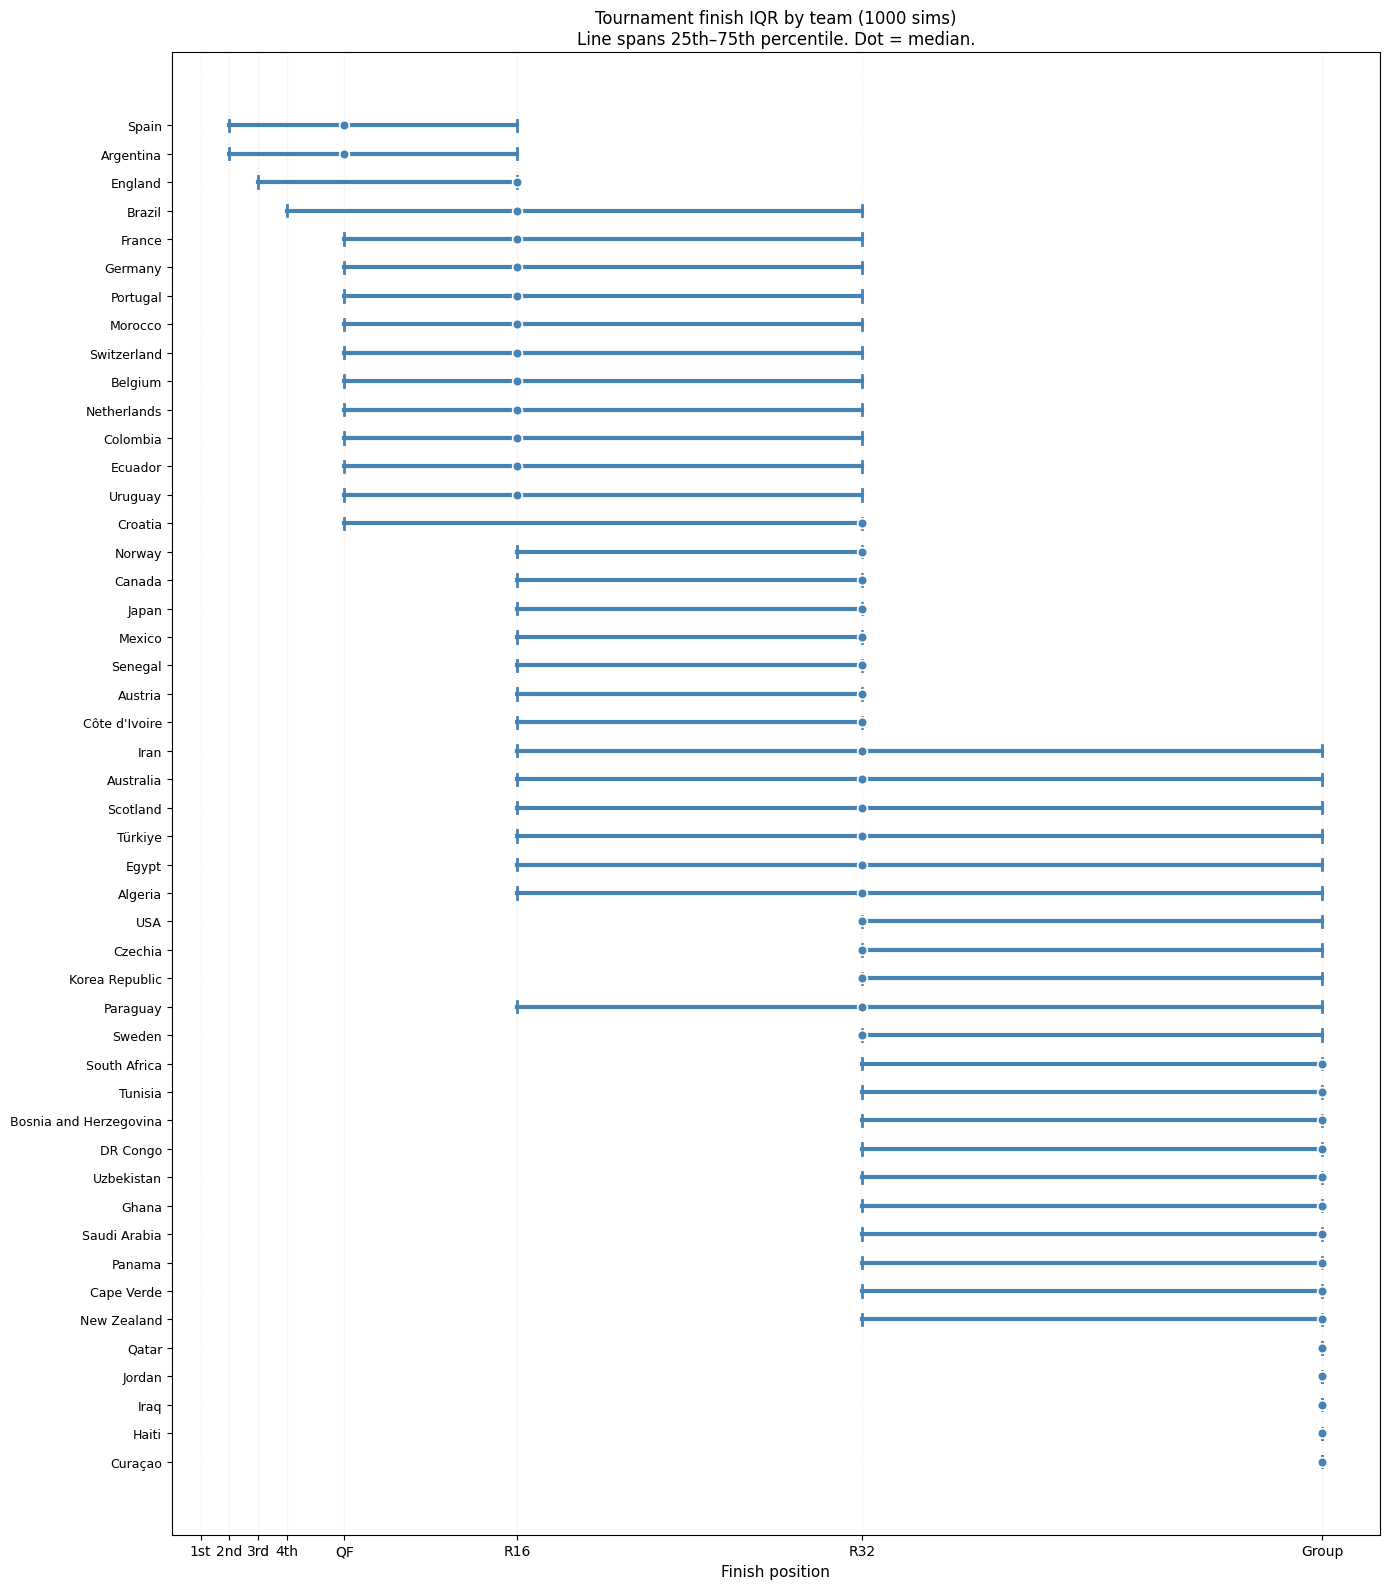

In [108]:
def plotTeamFinishIQR(positionsByTeam, mcResults, figsize=(14, 16),
                     sortBy='meanFinish', lineColor='steelblue'):
    """Horizontal IQR plot: line spans 25th to 75th percentile of finishes,
    with median marker."""
    
    positionBuckets = [1, 2, 3, 4, 6, 12, 24, 40]
    bucketLabels = {1: '1st', 2: '2nd', 3: '3rd', 4: '4th',
                    6: 'QF', 12: 'R16', 24: 'R32', 40: 'Group'}
    
    sortedTeams = mcResults.sort_values(sortBy)['team'].tolist()
    nTeams = len(sortedTeams)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, team in enumerate(sortedTeams):
        ps = positionsByTeam[team]
        q25 = np.percentile(ps, 25)
        q75 = np.percentile(ps, 75)
        med = np.median(ps)
        
        # IQR line
        ax.plot([q25, q75], [i, i], color=lineColor, linewidth=3, zorder=1)
        # End caps
        ax.plot([q25, q25], [i - 0.2, i + 0.2], color=lineColor, linewidth=2, zorder=1)
        ax.plot([q75, q75], [i - 0.2, i + 0.2], color=lineColor, linewidth=2, zorder=1)
        # Median
        ax.plot(med, i, 'o', color=lineColor, markersize=7,
                markeredgecolor='white', markeredgewidth=1.2, zorder=2)
    
    ax.set_yticks(range(nTeams))
    ax.set_yticklabels(sortedTeams, fontsize=9)
    ax.invert_yaxis()
    
    ax.set_xticks(positionBuckets)
    ax.set_xticklabels([bucketLabels[b] for b in positionBuckets], fontsize=10)
    ax.set_xlabel('Finish position', fontsize=11)
    ax.set_xlim(0, 42)
    
    ax.set_title(f'Tournament finish IQR by team ({len(positionsByTeam[sortedTeams[0]])} sims)\n'
                 f'Line spans 25th–75th percentile. Dot = median.',
                 fontsize=12)
    
    ax.grid(axis='x', linestyle=':', alpha=0.3)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig, ax


fig, ax = plotTeamFinishIQR(positionsByTeam, mcResults)
plt.show()

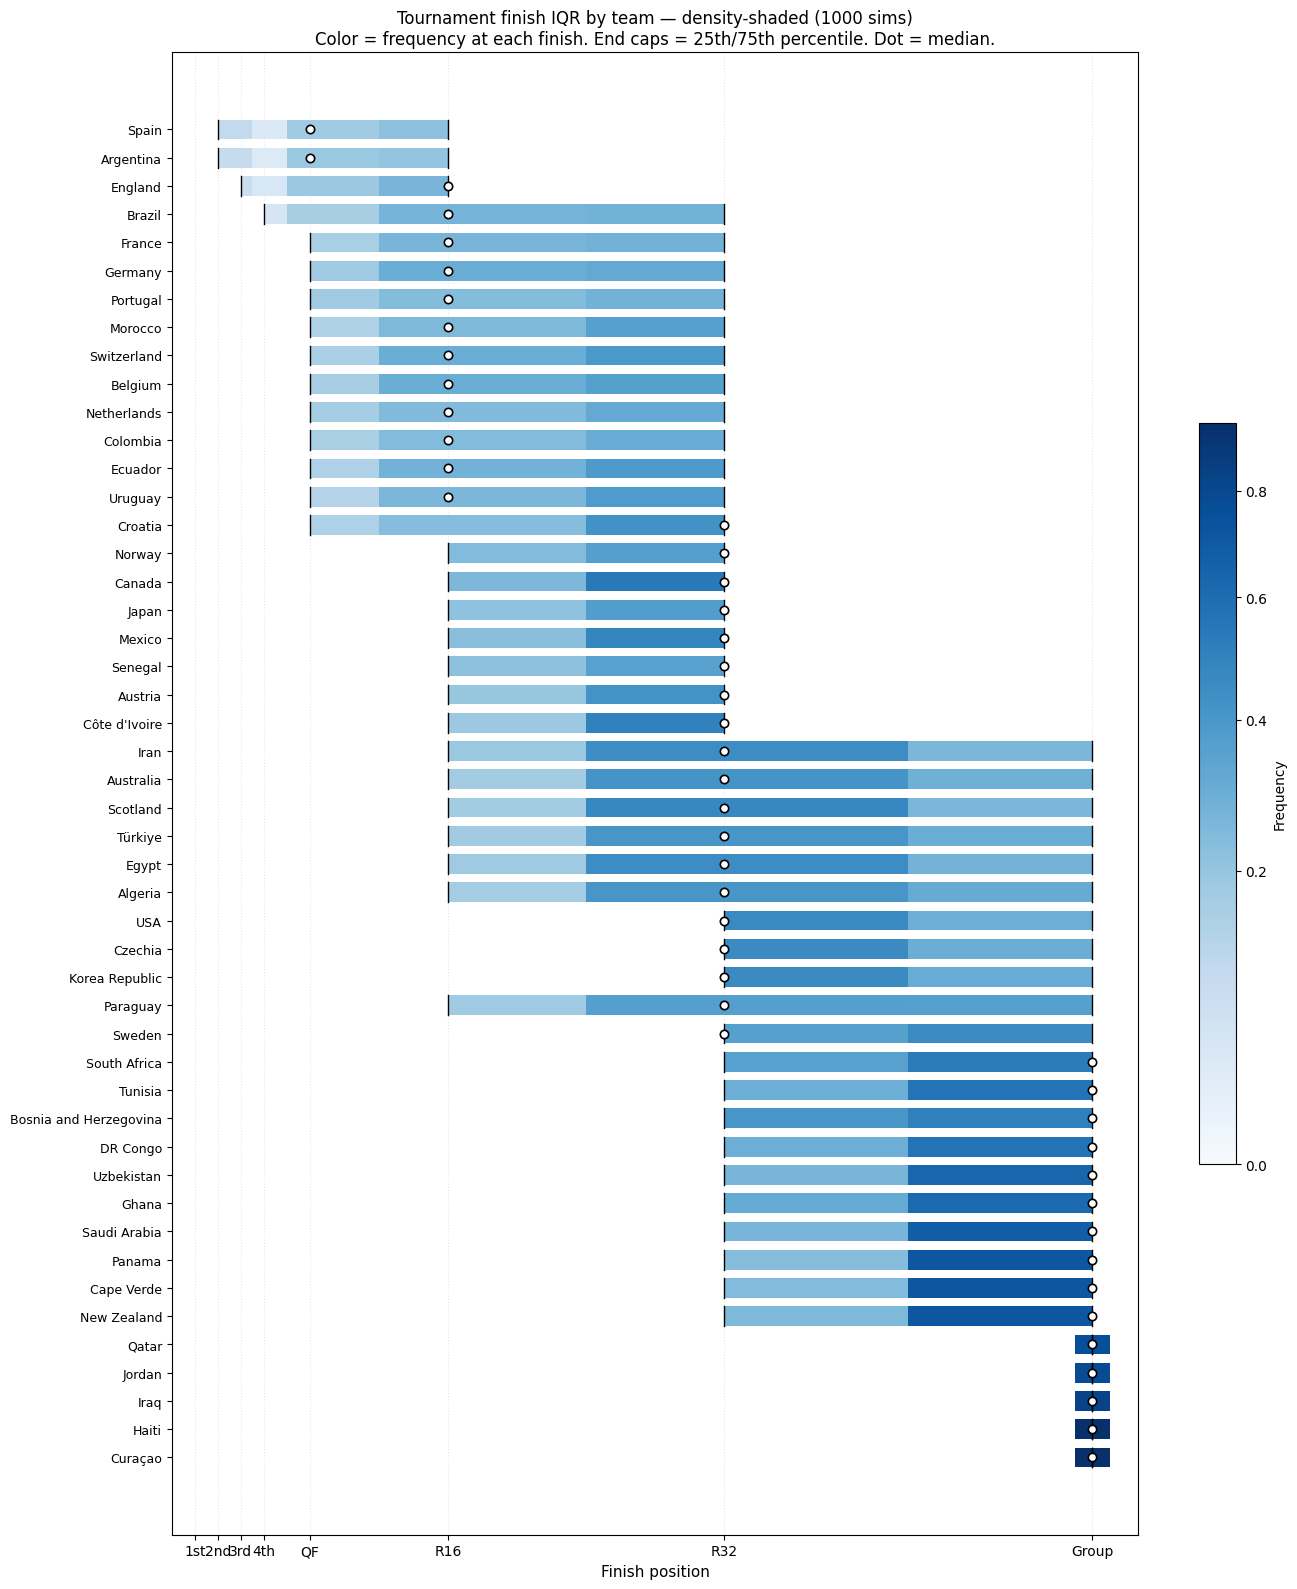

In [109]:
def plotTeamFinishIQRDensity(positionsByTeam, mcResults, figsize=(14, 16),
                             cmap='Blues', sortBy='meanFinish'):
    """IQR strip per team: line spans 25th–75th percentile, colored by frequency
    along that range. Median marker overlaid."""
    
    positionBuckets = [1, 2, 3, 4, 6, 12, 24, 40]
    bucketLabels = {1: '1st', 2: '2nd', 3: '3rd', 4: '4th',
                    6: 'QF', 12: 'R16', 24: 'R32', 40: 'Group'}
    
    sortedTeams = mcResults.sort_values(sortBy)['team'].tolist()
    nTeams = len(sortedTeams)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Global max for consistent color scaling — only count freq within each team's IQR
    globalMax = 0
    for team in sortedTeams:
        ps = positionsByTeam[team]
        q25, q75 = np.percentile(ps, 25), np.percentile(ps, 75)
        inIQR = [p for p in ps if q25 <= p <= q75]
        n = len(ps)
        for b in positionBuckets:
            if q25 <= b <= q75:
                freq = inIQR.count(b) / n
                if freq > globalMax:
                    globalMax = freq
    
    cmapObj = plt.get_cmap(cmap)
    norm = mcolors.PowerNorm(gamma=0.6, vmin=0, vmax=globalMax)
    
    bucketArr = sorted(positionBuckets)
    
    for i, team in enumerate(sortedTeams):
        ps = positionsByTeam[team]
        q25 = np.percentile(ps, 25)
        q75 = np.percentile(ps, 75)
        med = np.median(ps)
        n = len(ps)
        
        # Buckets within IQR
        bucketsInIQR = [b for b in bucketArr if q25 <= b <= q75]
        
        if len(bucketsInIQR) == 0:
            # IQR collapses below smallest bucket — shouldn't happen, but guard
            continue
        
        if len(bucketsInIQR) == 1:
            # IQR collapses to single bucket → draw a small dark patch
            b = bucketsInIQR[0]
            freq = ps.count(b) / n
            ax.barh(i, 1.5, left=b - 0.75, height=0.7,
                    color=cmapObj(norm(freq)), edgecolor='none', zorder=1)
        else:
            # Draw segments between consecutive buckets in IQR
            for j, b in enumerate(bucketsInIQR):
                freq = ps.count(b) / n
                # Segment edges: midpoints to neighbors, clipped to IQR bounds
                leftNeighbor = bucketsInIQR[j-1] if j > 0 else None
                rightNeighbor = bucketsInIQR[j+1] if j < len(bucketsInIQR) - 1 else None
                
                leftEdge = (leftNeighbor + b) / 2 if leftNeighbor is not None else q25
                rightEdge = (b + rightNeighbor) / 2 if rightNeighbor is not None else q75
                
                # Clip to IQR
                leftEdge = max(leftEdge, q25)
                rightEdge = min(rightEdge, q75)
                width = rightEdge - leftEdge
                
                ax.barh(i, width, left=leftEdge, height=0.7,
                        color=cmapObj(norm(freq)), edgecolor='none', zorder=1)
        
        # End caps at q25 and q75
        ax.plot([q25, q25], [i - 0.35, i + 0.35], color='black', linewidth=1, zorder=2)
        ax.plot([q75, q75], [i - 0.35, i + 0.35], color='black', linewidth=1, zorder=2)
        
        # Median marker
        ax.plot(med, i, 'o', color='white', markersize=6,
                markeredgecolor='black', markeredgewidth=1.2, zorder=3)
    
    ax.set_yticks(range(nTeams))
    ax.set_yticklabels(sortedTeams, fontsize=9)
    ax.invert_yaxis()
    
    ax.set_xticks(positionBuckets)
    ax.set_xticklabels([bucketLabels[b] for b in positionBuckets], fontsize=10)
    ax.set_xlabel('Finish position', fontsize=11)
    ax.set_xlim(0, 42)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, label='Frequency')
    
    ax.set_title(f'Tournament finish IQR by team — density-shaded '
                 f'({len(positionsByTeam[sortedTeams[0]])} sims)\n'
                 f'Color = frequency at each finish. End caps = 25th/75th percentile. Dot = median.',
                 fontsize=12)
    
    ax.grid(axis='x', linestyle=':', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig, ax


fig, ax = plotTeamFinishIQRDensity(positionsByTeam, mcResults)
plt.show()

## 10. Validation

Sanity checks and comparison to the ELO-only version.

In [110]:
# Sanity
assert abs(mcResults['titleProb'].sum() - 1.0) < 1e-9
print(f"✓ Title probabilities sum to {mcResults['titleProb'].sum():.4f}")
print(f"✓ Max title prob: {mcResults['titleProb'].max():.3f} ({mcResults.iloc[0]['team']})")
print(f"✓ Teams winning at least once: {(mcResults['titleProb'] > 0).sum()} of 48")
print(f"\nHost nations:")
for host in sorted(HOST_NATIONS):
    row = mcResults[mcResults['team'] == host].iloc[0]
    print(f"  {host}: title={row['titleProb']:.3f}, SF={row['sfProb']:.3f}")

✓ Title probabilities sum to 1.0000
✓ Max title prob: 0.190 (Argentina)
✓ Teams winning at least once: 34 of 48

Host nations:
  Canada: title=0.002, SF=0.028
  Mexico: title=0.004, SF=0.043
  USA: title=0.001, SF=0.027


## 11. Notes and next steps

**Where this model is honest about its limits:**
1. **Independence assumption** — the model treats home goals and away goals as independent Poissons. In reality there's mild negative correlation in low-scoring matches (Dixon-Coles tau correction fixes this; worth adding for marginal improvement)
2. **No score-state effects** — once a team is up 3-0 they ease off; the model doesn't capture this
3. **No squad turnover** — Germany's 2018 squad is 70% different from 2026's, but the model assumes "Germany" is a stable entity. Time decay partially mitigates this
4. **Importance weights are heuristic** — academics have studied this; my weights are reasonable but not calibrated

**For further work**:
- **Dixon-Coles correction**: 5-line addition to the likelihood that improves low-score predictions
- **Calibration check**: run model on 2022 WC data only and see if it would have predicted Argentina winning at a reasonable rate
- **Compare to your existing ELO**: pull `elo_ratings.csv` from `calculate_elo.py` output, take final ELO per team, and see if Maher attack-defense correlates well with ELO. They should — strong teams should have high attack AND low defense